DataSet a utilizar: Iris.
Este es un clásico en la clasificación multiclase. Contiene 150 muestras de flores Iris, divididas en tres clases (Iris setosa, Iris versicolor e Iris virginica), con cuatro características cada una (longitud y anchura de sépalo y pétalo).

- Prepara los datos y aplica los distintos algoritmos svm vistos.
- Compara resultados.
- Ten en cuenta que en estos casos es multiclase.

# 1. Importación del modelo

In [3]:
# Importación del modelo
from sklearn.datasets import load_iris

iris = load_iris()

X = iris.data      # características (features)
y = iris.target    # etiquetas (clases)

print(iris.feature_names)

['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']


# 2. Imports

In [5]:
# Imports
%matplotlib inline
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.model_selection import train_test_split
import numpy as np
from sklearn.metrics import f1_score
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.pipeline import Pipeline

In [6]:
import warnings
# Ignoramos algunos warnings que se producen por invocar el pipeline sin el nombre de las características
warnings.filterwarnings('ignore', category=UserWarning, message='.*X does not have valid feature names.*')
warnings.filterwarnings('ignore', category=RuntimeWarning, message='.*invalid value encountered in subtract.*')

## 2.1 Funciones auxiliares

In [7]:
# Construcción de una función que realice el particionado completo. Divide el conjunto de datos en entrenamiento, validación y test
def train_val_test_split(df, rstate=42, shuffle=True, stratify=None):
    strat = df[stratify] if stratify else None
    train_set, test_set = train_test_split(
        df, test_size=0.4, random_state=rstate, shuffle=shuffle, stratify=strat)
    strat = test_set[stratify] if stratify else None
    val_set, test_set = train_test_split(
        test_set, test_size=0.5, random_state=rstate, shuffle=shuffle, stratify=strat)
    return (train_set, val_set, test_set)

In [8]:
# Representación gráfica del límite de decisión (veremos distintos tipos de límites de decisión)
def plot_svc_decision_boundary(svm_clf, xmin, xmax):
    w = svm_clf.coef_[0]
    b = svm_clf.intercept_[0]

    # At the decision boundary, w0*x0 + w1*x1 + b = 0
    # => x1 = -w0/w1 * x0 - b/w1
    x0 = np.linspace(xmin, xmax, 200)
    decision_boundary = -w[0]/w[1] * x0 - b/w[1]

    margin = 1/w[1]
    gutter_up = decision_boundary + margin
    gutter_down = decision_boundary - margin

    svs = svm_clf.support_vectors_
    plt.scatter(svs[:, 0], svs[:, 1], s=180, facecolors='#FFAAAA')
    plt.plot(x0, decision_boundary, "k-", linewidth=2)
    plt.plot(x0, gutter_up, "k--", linewidth=2)
    plt.plot(x0, gutter_down, "k--", linewidth=2)

# 3. Lectua del cojunto de datos

In [24]:
iris = load_iris()
df = pd.DataFrame(iris.data, columns=iris.feature_names)
# Se le añade la columna target por que solo tienes datos de entrada, pero no tienes la salida (la clasificación)
df['target'] = iris.target

# Al solo imprimir 10 líneas solo vemos la clase 0 pero la clase 1 y 2 también existe
df.head(10)

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0
5,5.4,3.9,1.7,0.4,0
6,4.6,3.4,1.4,0.3,0
7,5.0,3.4,1.5,0.2,0
8,4.4,2.9,1.4,0.2,0
9,4.9,3.1,1.5,0.1,0


In [26]:
df.describe()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333,1.000000
std,0.828066,0.435866,1.765298,0.762238,0.819232
min,4.300000,2.000000,1.000000,0.100000,0.000000
25%,5.100000,2.800000,1.600000,0.300000,0.000000
50%,5.800000,3.000000,4.350000,1.300000,1.000000
75%,6.400000,3.300000,5.100000,1.800000,2.000000
max,7.900000,4.400000,6.900000,2.500000,2.000000


In [27]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   target             150 non-null    int64  
dtypes: float64(4), int64(1)
memory usage: 6.0 KB


In [28]:
# Ejemplos de cada clase
df["target"].value_counts()

target
0    50
1    50
2    50
Name: count, dtype: int64

In [29]:
# Comprobación de si existen valores nulos
is_null = df.isna().any()
is_null[is_null]

Series([], dtype: bool)

In [30]:
# Comprobación de la existencia de valores infinitos
is_inf = df.isin([np.inf, -np.inf]).any()
is_inf[is_inf]

Series([], dtype: bool)

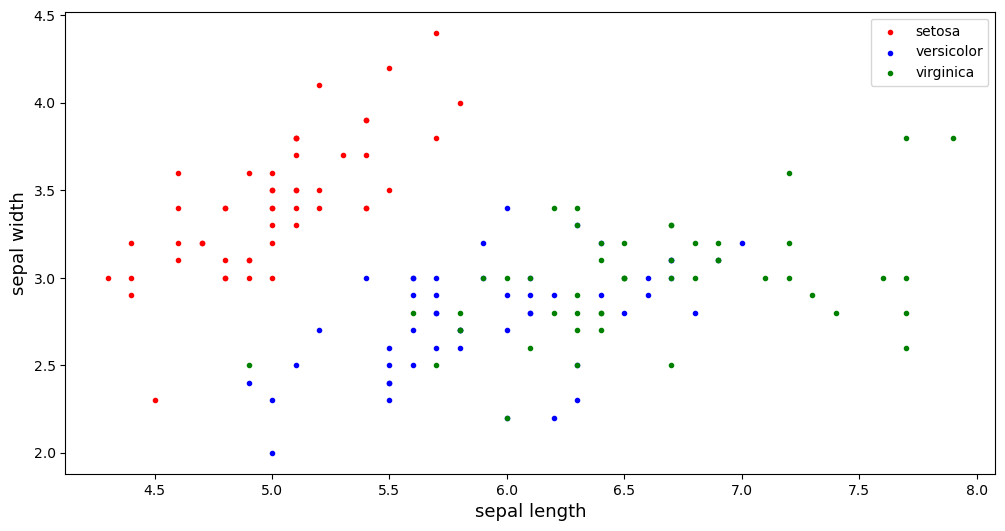

In [31]:
# Representación gráfica de dos características
plt.figure(figsize=(12, 6))
plt.scatter(df["sepal length (cm)"][df['target'] == 0], df["sepal width (cm)"][df['target'] == 0], c="r", marker=".", label="setosa")
plt.scatter(df["sepal length (cm)"][df['target'] == 1], df["sepal width (cm)"][df['target'] == 1], c="b", marker=".", label="versicolor")
plt.scatter(df["sepal length (cm)"][df['target'] == 2], df["sepal width (cm)"][df['target'] == 2], c="g", marker=".", label="virginica")
plt.xlabel("sepal length", fontsize=13)
plt.ylabel("sepal width", fontsize=13)
plt.legend()
plt.show()

# 4. División del conjunto de datos

In [32]:
# División del conjunto de datos
train_set, val_set, test_set = train_val_test_split(df)

In [33]:
# De las X (entrada) elimino la columna target puesto que es el resultado final (salida)
# De las y (salida) me quedo con la columna target solo
X_train = train_set.drop("target", axis=1)
y_train = train_set["target"].copy()

X_val = val_set.drop("target", axis=1)
y_val = val_set["target"].copy()

X_test = test_set.drop("target", axis=1)
y_test = test_set["target"].copy()

# 5. Preparación del conjunto de datos

NOTA: No tiene valores infinitos y no tiene valores nulos por lo tanto no se aplican esas modificaciones

# 6. SMV: Kernel lineal

In [70]:
# Seleccionamos solo las primeras 2 columnas para poder graficar en 2D
X_train = X_train[["sepal length (cm)", "sepal width (cm)"]]
X_val = X_val[["sepal length (cm)", "sepal width (cm)"]]

from sklearn.svm import SVC
svm_clf = SVC(kernel="linear", C=1)
svm_clf.fit(X_train, y_train) # Entrenamos con 2 dimensiones

,C,1
,kernel,'linear'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [66]:
def plot_svc_decision_boundary(svm_clf, xmin, xmax):
    w = svm_clf.coef_[0]
    b = svm_clf.intercept_[0]

    x0 = np.linspace(xmin, xmax, 200)
    decision_boundary = -w[0]/w[1] * x0 - b/w[1]

    margin = 1/w[1]
    gutter_up = decision_boundary + margin
    gutter_down = decision_boundary - margin

    svs = svm_clf.support_vectors_
    plt.scatter(svs[:, 0], svs[:, 1], s=180, facecolors='#FFAAAA')
    plt.plot(x0, decision_boundary, "k-", linewidth=2)
    plt.plot(x0, gutter_up, "k--", linewidth=2)
    plt.plot(x0, gutter_down, "k--", linewidth=2)

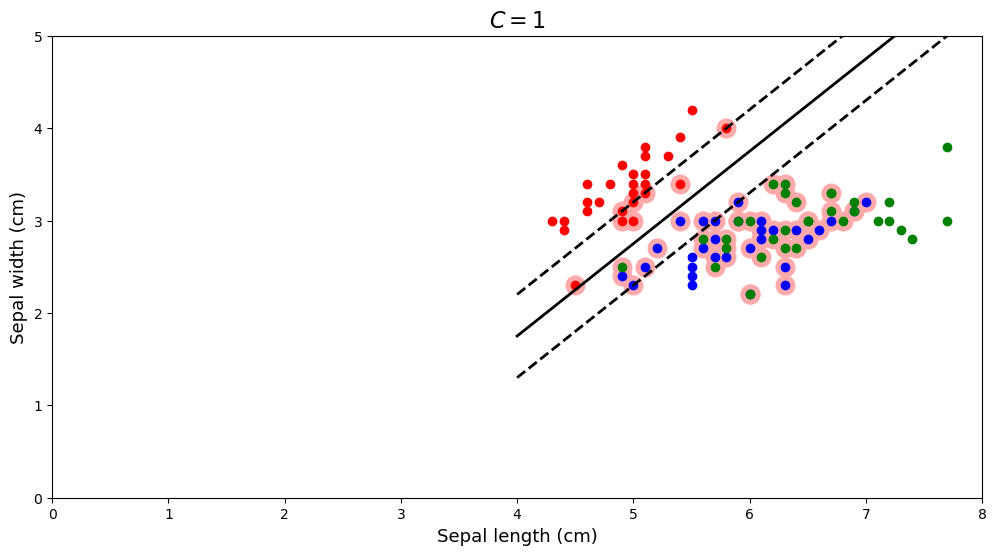

In [67]:
plt.figure(figsize=(12, 6))

plt.plot(X_train.values[:, 0][y_train==0], X_train.values[:, 1][y_train==0], "ro")
plt.plot(X_train.values[:, 0][y_train==1], X_train.values[:, 1][y_train==1], "bo")
plt.plot(X_train.values[:, 0][y_train==2], X_train.values[:, 1][y_train==2], "go")

# Dibujamos el límite de decisión generado por el modelo SVM
plot_svc_decision_boundary(svm_clf, 4, 10)

plt.title("$C = {}$".format(svm_clf.C), fontsize=16)

plt.axis([0, 8, 0, 5])

plt.xlabel("Sepal length (cm)", fontsize=13)
plt.ylabel("Sepal width (cm)", fontsize=13)

plt.show()

In [69]:
y_pred = svm_clf.predict(X_val)
print("F1 Score:", f1_score(y_val, y_pred, average="weighted"))

F1 Score: 0.8584615384615385


# 7. SMV Kernel no lineal

## 7.1 Polynomial Kernel (I)

In [72]:
from sklearn.datasets import make_moons
from sklearn.svm import LinearSVC
from sklearn.preprocessing import PolynomialFeatures

polynomial_svm_clf = Pipeline([
    #Convierto características de entrada en polinómicas y llega a un
    #grado máximo de 3
        ("poly_features", PolynomialFeatures(degree=3)),
    #Escalo mis características
        ("scaler", StandardScaler()),
    #Entreno un algoritmo lineal como el anterior pero con características
    #polinómicas y así tengo un resultado con límite no lineal
        ("svm_clf", LinearSVC(C=20, loss="hinge", random_state=42, max_iter=100000, dual=True))
    ])

polynomial_svm_clf.fit(X_train, y_train)

,steps,"[('poly_features', ...), ('scaler', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,degree,3
,interaction_only,False
,include_bias,True
,order,'C'
,copy,True
,with_mean,True
,with_std,True


In [73]:
def plot_dataset(X, y):
    plt.plot(X[:, 0][y==1], X[:, 1][y==1], "g.")
    plt.plot(X[:, 0][y==0], X[:, 1][y==0], "b.")

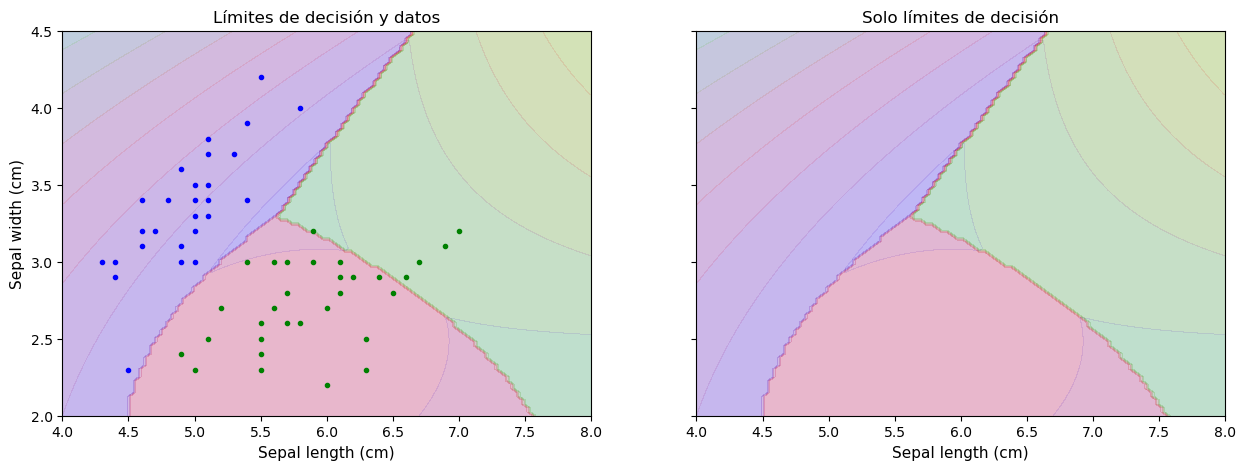

In [80]:
def plot_predictions(clf, axes):
    x0s = np.linspace(axes[0], axes[1], 100)
    x1s = np.linspace(axes[2], axes[3], 100)
    x0, x1 = np.meshgrid(x0s, x1s)
    X = np.c_[x0.ravel(), x1.ravel()]
    
    y_pred = clf.predict(X).reshape(x0.shape)
    
    # Para 3 clases, decision_function devuelve (N, 3). 
    # Usamos np.max para obtener la confianza de la clase ganadora en cada punto.
    decisions = clf.decision_function(X)
    y_decision = np.max(decisions, axis=1).reshape(x0.shape)
    
    # Dibujamos las áreas de color sólido para cada clase
    plt.contourf(x0, x1, y_pred, cmap=plt.cm.brg, alpha=0.2)
    # Dibujamos sombreado basado en la confianza (función de decisión)
    plt.contourf(x0, x1, y_decision, cmap=plt.cm.brg, alpha=0.1) 

fig, axes_plt = plt.subplots(ncols=2, figsize=(15, 5), sharey=True)
plt.sca(axes_plt[0])
X_train = X_train[["sepal length (cm)", "sepal width (cm)"]]
plot_dataset(X_train.values, y_train) 
plot_predictions(polynomial_svm_clf, [4, 8, 2, 4.5])
plt.xlabel("Sepal length (cm)", fontsize=11)
plt.ylabel("Sepal width (cm)", fontsize=11)
plt.title("Límites de decisión y datos")

# Segundo subgráfico
plt.sca(axes_plt[1])
plot_predictions(polynomial_svm_clf, [4, 8, 2, 4.5])
plt.xlabel("Sepal length (cm)", fontsize=11)
plt.title("Solo límites de decisión")

plt.show()

In [82]:
y_pred = polynomial_svm_clf.predict(X_val)

In [85]:
print("F1 Score:", f1_score(y_val, y_pred, average="weighted"))

F1 Score: 0.7705685618729097


# 7.2 Polynomial Kernel (II)

In [86]:
svm_clf = SVC(kernel="poly", degree=3, coef0=10, C=20)
svm_clf.fit(X_train, y_train)

,C,20
,kernel,'poly'
,degree,3
,gamma,'scale'
,coef0,10
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


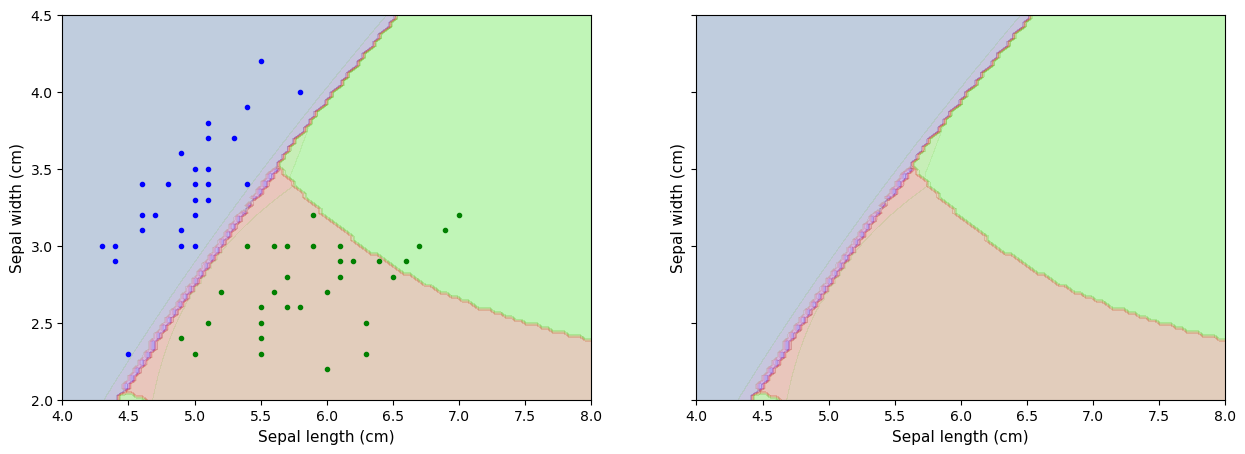

In [89]:
fig, axes = plt.subplots(ncols=2, figsize=(15,5), sharey=True)
plt.sca(axes[0])
plot_dataset(X_train.values, y_train)
plot_predictions(svm_clf, [4, 8, 2, 4.5])
plt.xlabel("Sepal length (cm)", fontsize=11)
plt.ylabel("Sepal width (cm)", fontsize=11)
plt.sca(axes[1])
plot_predictions(svm_clf, [4, 8, 2, 4.5])
plt.xlabel("Sepal length (cm)", fontsize=11)
plt.ylabel("Sepal width (cm)", fontsize=11)
plt.show()

In [91]:
svm_clf = SVC(kernel="poly", degree=3, coef0=10, C=40)
svm_clf.fit(X_train, y_train)

,C,40
,kernel,'poly'
,degree,3
,gamma,'scale'
,coef0,10
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [93]:
y_pred = svm_clf.predict(X_val)

In [94]:
print("F1 Score:", f1_score(y_val, y_pred, average="weighted"))

F1 Score: 0.7705685618729097


# 7.3 Gaussian Kernel (II)

In [96]:
rbf_kernel_svm_clf = Pipeline([
            ("scaler", RobustScaler()),
            ("svm_clf", SVC(kernel="rbf", gamma=0.5, C=1000))
        ])

rbf_kernel_svm_clf.fit(X_train, y_train)

,steps,"[('scaler', ...), ('svm_clf', ...)]"
,transform_input,None
,memory,None
,verbose,False
,with_centering,True
,with_scaling,True
,quantile_range,"(25.0, ...)"
,copy,True
,unit_variance,False
,C,1000
,kernel,'rbf'


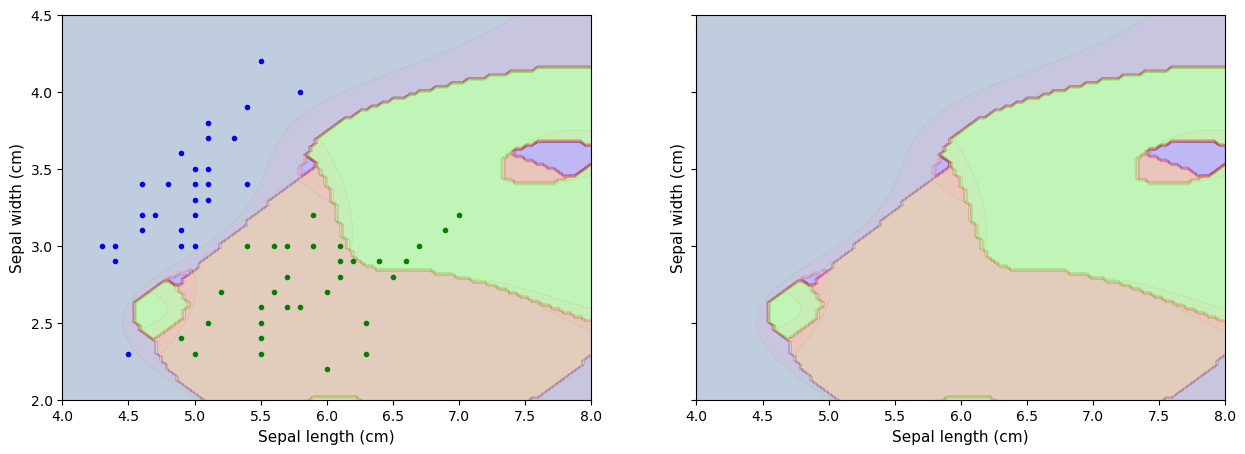

In [98]:
fig, axes = plt.subplots(ncols=2, figsize=(15,5), sharey=True)
plt.sca(axes[0])
plot_dataset(X_train.values, y_train)
plot_predictions(rbf_kernel_svm_clf, [4, 8, 2, 4.5])
plt.xlabel("Sepal length (cm)", fontsize=11)
plt.ylabel("Sepal width (cm)", fontsize=11)
plt.sca(axes[1])
plot_predictions(rbf_kernel_svm_clf, [4, 8, 2, 4.5])
plt.xlabel("Sepal length (cm)", fontsize=11)
plt.ylabel("Sepal width (cm)", fontsize=11)
plt.show()

In [99]:
rbf_kernel_svm_clf = Pipeline([
            ("scaler", RobustScaler()),
            ("svm_clf", SVC(kernel="rbf", gamma=0.05, C=1000))
        ])

rbf_kernel_svm_clf.fit(X_train, y_train)

,steps,"[('scaler', ...), ('svm_clf', ...)]"
,transform_input,None
,memory,None
,verbose,False
,with_centering,True
,with_scaling,True
,quantile_range,"(25.0, ...)"
,copy,True
,unit_variance,False
,C,1000
,kernel,'rbf'


In [101]:
y_pred = rbf_kernel_svm_clf.predict(X_val)

In [102]:
print("F1 Score:", f1_score(y_val, y_pred, average="weighted"))

F1 Score: 0.7705685618729097
